In [1]:
# Imports
from functools import partial

import jax
from jax import numpy as jnp
from jax import random, vmap

import optax
from flax import nnx
from helper import DataLoader

from IPython.display import HTML
import ipywidgets as widgets

from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from plotting import plot_prediction_with_uncertainty, plot_uncertainty_and_maximum

from laplax.curv import create_ggn_mv, create_posterior_fn
from laplax.eval.pushforward import (
    lin_pred_mean,
    lin_pred_std,
    lin_pred_var,
    lin_setup,
    set_lin_pushforward,
)

seed = 2392385

In [2]:
# Overview over active learning goal and procedure

In [3]:
# Data creation: Function that samples a y value given x
# and creates some small train set


def sample_target(x, key, sample_variance=0.0005):
    """Sample a target (label) for a given datapoint x.

    Args:
        x: x-value for which to sample a label
        key: PRNGKey to use for sampling
        sample_variance: Strength of added noise

    Returns:
        $y = f(x) + eps$ where $f$ is the sinc function
        and eps is Gaussian noise with mean zero and variance given by 'sample_variance'
    """
    x = x.squeeze()  # Assume one-dimensional x values
    y_true = jnp.sinc(x)
    noise = random.normal(key, y_true.shape) * jnp.sqrt(sample_variance)
    return y_true + noise


def true_function(xs):
    key = random.key(seed)
    keys = random.split(key, len(xs))

    function = partial(sample_target, sample_variance=0.0)
    return vmap(function)(xs, keys)


x = jnp.concatenate((jnp.linspace(0.2, 2, 2), jnp.linspace(3.5, 5, 2)))[:, None]
n_initial_datapoints = x.shape[0]

key = random.key(seed)
keys = random.split(key, len(x))

prior_variance = 0.01

sample = partial(sample_target, sample_variance=prior_variance)

y = vmap(sample)(x, keys)[:, None]

dataloader = DataLoader(x, y, batch_size=10)

In [4]:
# Model definition


class Model(nnx.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, rngs):
        self.linear1 = nnx.Linear(in_channels, hidden_channels, rngs=rngs)
        self.linear2 = nnx.Linear(hidden_channels, hidden_channels, rngs=rngs)
        self.linear3 = nnx.Linear(hidden_channels, hidden_channels, rngs=rngs)
        self.linear4 = nnx.Linear(hidden_channels, hidden_channels, rngs=rngs)
        self.linear5 = nnx.Linear(hidden_channels, out_channels, rngs=rngs)

    def __call__(self, x):
        x = nnx.tanh(self.linear1(x))
        x = nnx.tanh(self.linear2(x))
        x = nnx.tanh(self.linear3(x))
        x = nnx.tanh(self.linear4(x))
        return self.linear5(x)


model = Model(in_channels=1, hidden_channels=64, out_channels=1, rngs=nnx.Rngs(seed))


@nnx.jit
def train_step(model, optimizer, x, y):
    def loss_fn(model):
        y_pred = model(x)  # Call methods directly
        return jnp.sum((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)  # Inplace updates

    return loss

In [5]:
def train_model(model, dataloader, n_epochs=1000, lr=1e-3):
    """Trains the given model on the data.

    Args:
        model: nnx.Module that represents the model, can be pretrained
        dataloader: Data on which to train
        n_epochs: Number of epochs to train for
        lr: learning rate for optimizer

    Returns:
        Trained model
    """
    optimizer = nnx.Optimizer(model, optax.adam(lr))

    # Train epoch
    for epoch in range(n_epochs):
        for x_batch, y_batch in dataloader:
            loss = train_step(model, optimizer, x_batch, y_batch)

        if epoch % 100 == 0 and epoch != 0:
            print(f"[epoch {epoch}]: loss: {loss:.4f}")
    print(f"Final loss: {loss:.4f}")
    return model

n_initial_epochs = 400

model = train_model(model, dataloader, n_epochs=n_initial_epochs)

[epoch 100]: loss: 0.0163
[epoch 200]: loss: 0.0074
[epoch 300]: loss: 0.0027
Final loss: 0.0000


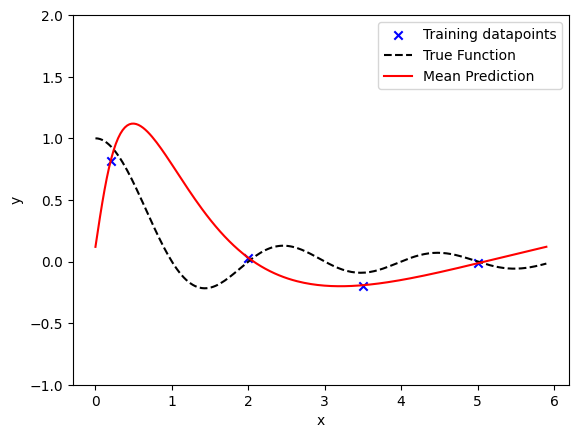

In [6]:
# Trained model visualization

x_pred = jnp.linspace(0.0, 5.9, 200)[:, None]

y_true = true_function(x_pred)
y_pred = model(x_pred)


fig, ax = plt.subplots()
plot_prediction_with_uncertainty(ax, dataloader, x_pred, y_true, y_pred, None)
plt.show()

In [7]:
def quantify_uncertainty(model, trainloader, x_pred, prior_precision):
    """Compute uncertainty of model on x_pred using laplax.

    Args:
        model: Model whose uncertainty is to be quantified
        trainloader: Datapoints used for training of model
        x_pred: Points where to quantify uncertainty
        prior_precision: Precision of assumed prior

    Returns:
        Tuple of prediction and its uncertainty (standard deviation)
    """
    graph_def, params = nnx.split(model)

    def model_fn(input, params):
        return nnx.call((graph_def, params))(input)[0]

    trainset = {"input": trainloader.X, "target": trainloader.y}

    ggn_mv = create_ggn_mv(
        model_fn,
        params,
        trainset,
        loss_fn="mse",
    )

    posterior_fn = create_posterior_fn(
        curv_type="full",
        mv=ggn_mv,
        layout=params,
    )

    set_prob_predictive = partial(
        set_lin_pushforward,
        model_fn=model_fn,
        mean_params=params,
        posterior_fn=posterior_fn,
        pushforward_fns=[
            lin_setup,
            lin_pred_mean,
            lin_pred_var,
            lin_pred_std,
        ],
    )
    prior_arguments = {"prior_prec": prior_precision}
    prob_predictive = set_prob_predictive(
        prior_arguments=prior_arguments,
    )

    pred = jax.vmap(prob_predictive)(x_pred)
    y_mean = pred["pred_mean"][:, 0]
    y_std = jnp.sqrt(pred["pred_var"][:, 0])

    return y_mean, y_std


prior_precision = 1.0 / prior_variance

y_mean, y_std = quantify_uncertainty(model, dataloader, x_pred, prior_precision)

In [8]:
def find_next_datapoint(x_pred, y_std):
    """Find the datapoint with largest uncertainty.

    Args:
        x_pred: Array of x values fo which uncertainty is known
        y_std: Uncertainty of x-values

    Returns:
        x-value with largest uncertainty
    """
    next_index = jnp.argmax(y_std)
    return x_pred[next_index]


next_datapoint = find_next_datapoint(x_pred, y_std)

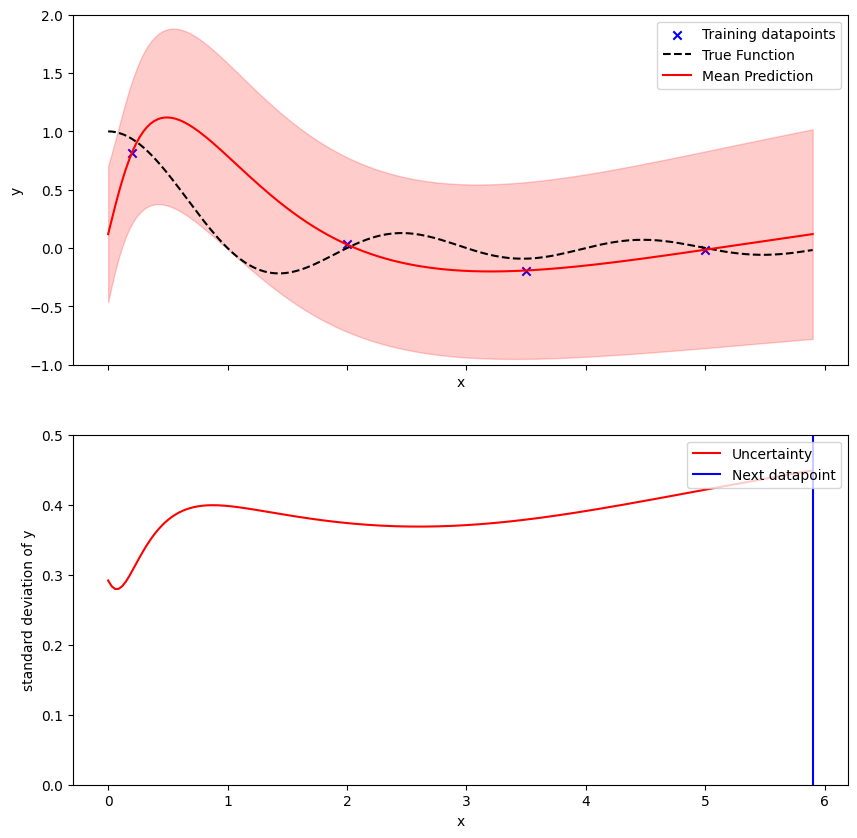

In [9]:
# Visualization with uncertainty, optimal next data point

fig, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(10, 10))
plot_prediction_with_uncertainty(ax1, dataloader, x_pred, y_true, y_mean, y_std)
plot_uncertainty_and_maximum(ax2, x_pred, y_std, next_datapoint)
plt.show()

In [10]:
# Active learning loop

learning_rounds = 16

key = random.key(21780)
keys = random.split(key, learning_rounds)

subplot1_data = []
subplot2_data = []

epochs_per_learning_round = 100

for i, key in enumerate(keys):
    print(f"Active learning round {i+1}")
    next_target = sample_target(next_datapoint, key, sample_variance=prior_variance)
    dataloader = dataloader.add(next_datapoint, next_target)
    train_model(model, dataloader, n_epochs=epochs_per_learning_round)
    y_mean, y_std = quantify_uncertainty(model, dataloader, x_pred, prior_precision)
    subplot1_data.append((dataloader, x_pred, y_true, y_mean, y_std))

    next_datapoint = find_next_datapoint(x_pred, y_std)
    subplot2_data.append((x_pred, y_std, next_datapoint))
    print("----------------------------")

Active Learning round 1
Final loss: 0.0108
----------------------------
Active Learning round 2
Final loss: 0.0271
----------------------------
Active Learning round 3
Final loss: 0.0314
----------------------------
Active Learning round 4
Final loss: 0.0333
----------------------------
Active Learning round 5
Final loss: 0.0287
----------------------------
Active Learning round 6
Final loss: 0.0155
----------------------------
Active Learning round 7
Final loss: 0.0100
----------------------------
Active Learning round 8
Final loss: 0.0009
----------------------------
Active Learning round 9
Final loss: 0.0053
----------------------------
Active Learning round 10
Final loss: 0.0050
----------------------------
Active Learning round 11
Final loss: 0.0153
----------------------------
Active Learning round 12
Final loss: 0.0031
----------------------------
Active Learning round 13
Final loss: 0.0175
----------------------------
Active Learning round 14
Final loss: 0.0048
----------------

In [11]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(10, 10))


def update(frame):
    ax1.clear()
    ax2.clear()
    artists1 = plot_prediction_with_uncertainty(ax1, *(subplot1_data[frame]))
    artists2 = plot_uncertainty_and_maximum(ax2, *(subplot2_data[frame]))
    return artists1 + artists2


animation = FuncAnimation(
    fig, update, frames=learning_rounds, interval=1500, repeat_delay=2000
)
plt.close(fig)  # Prevent duplicate figure
HTML(animation.to_jshtml())

## Comparison to passive learning

To see the difference active learning makes, we compare the learned model to one that is passively, i.e. one where the datapoints are not chosen smartly.

For a fair comparison, we train the passive model with the same number of datapoints and for the same overall number of epochs. Note however that in active learning, epochs are much smaller in the beginning.

In [12]:
lib_dropdown = widgets.Dropdown(
    options=["Random Uniform", "Equidistant"],
    value="Random Uniform",
    description="Choose:",
)
display(lib_dropdown)

Dropdown(description='Choose:', options=('Random Uniform', 'Equidistant'), value='Random Uniform')

[epoch 100]: loss: 0.1782
[epoch 200]: loss: 0.2000
[epoch 300]: loss: 0.2598
[epoch 400]: loss: 0.2546
[epoch 500]: loss: 0.2090
[epoch 600]: loss: 0.1217
[epoch 700]: loss: 0.1425
[epoch 800]: loss: 0.0938
[epoch 900]: loss: 0.0711
[epoch 1000]: loss: 0.0495
[epoch 1100]: loss: 0.0486
[epoch 1200]: loss: 0.0384
[epoch 1300]: loss: 0.0967
[epoch 1400]: loss: 0.0319
[epoch 1500]: loss: 0.0295
[epoch 1600]: loss: 0.0239
[epoch 1700]: loss: 0.0428
[epoch 1800]: loss: 0.0133
[epoch 1900]: loss: 0.0265
Final loss: 0.0410


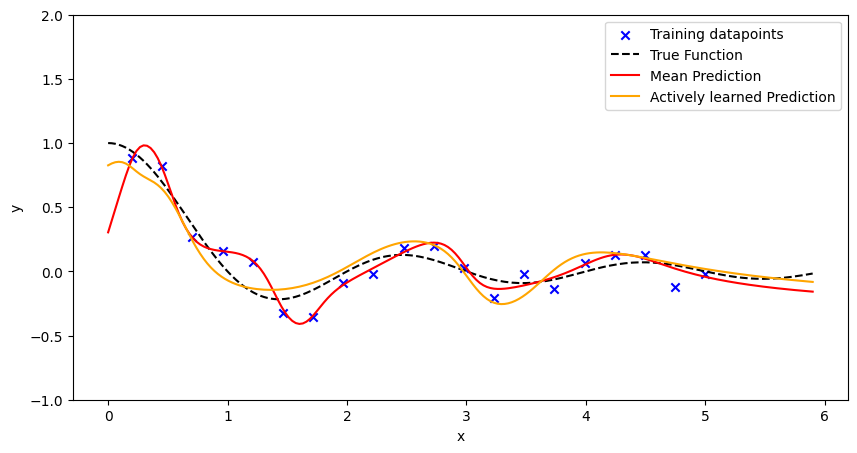

RMSE of passive model to true function: 0.40
RMSE of active model to true function: 0.08


In [17]:
n_passive_datapoints = n_initial_datapoints + learning_rounds
n_passive_epochs = n_initial_epochs + learning_rounds * epochs_per_learning_round

# Sample x-values according to selection
sampling_type = lib_dropdown.value
random_uniform = random.uniform(key, shape=(20, 1), minval=0.2, maxval=5.0)
equidistant = jnp.linspace(0.2, 5, 20)[:, None]
passive_xs = random_uniform if sampling_type == "Random Uniform" else equidistant

# Sample y-values
keys = random.split(key, len(passive_xs))
passive_ys = vmap(sample)(passive_xs, keys)[:, None]

# Train model with sampled data
passive_dataloader = DataLoader(passive_xs, passive_ys, batch_size=10)
assert len(passive_dataloader) == len(dataloader)
passive_model = Model(
    in_channels=1, hidden_channels=64, out_channels=1, rngs=nnx.Rngs(seed)
)
passive_model = train_model(passive_model, passive_dataloader, n_epochs=n_passive_epochs)

# Predict with passive model
y_pred_passive = passive_model(x_pred)

# Plot
fig, ax = plt.subplots(figsize=(10,5))
plot_prediction_with_uncertainty(
    ax, passive_dataloader, x_pred, y_true, y_pred_passive, None
)
ax.plot(x_pred, y_mean, color="orange", label="Actively learned Prediction")
ax.legend()
plt.show()

# Compute RMSE to exact function
passive_RMSE = jnp.sqrt(jnp.mean((y_pred_passive - y_true)**2))
active_RMSE = jnp.sqrt(jnp.mean((y_mean - y_true)**2))

print(f"RMSE of passive model to true function: {passive_RMSE:.2f}")
print(f"RMSE of active model to true function: {active_RMSE:.2f}")